# TỔNG HỢP PHÁT HIỆN & KHUYẾN NGHỊ DOANH NGHIỆP (FINAL INSIGHTS & BUSINESS RECOMMENDATIONS)

Notebook này tổng hợp các phát hiện từ tất cả các phân tích trước đó và đưa ra các khuyến nghị doanh nghiệp có thể triển khai dựa trên kết quả kiểm định A/B test.

**Tóm tắt tiến trình phân tích (Analysis Pipeline):**

| Notebook | Chủ đề |
|---|---|
| 01 | Hiểu dữ liệu (Data Understanding) |
| 02 | Phân tích khám phá dữ liệu (Exploratory Data Analysis) |
| 03 | Kiểm định thống kê A/B test (Statistical Inference) |
| 04 | Các phương pháp tái mẫu (Resampling Methods - Bootstrap) |
| 05 | Phân tích lực kiểm định (Power Analysis) |
| 06 | Phân tích hồi quy (Regression Analysis) |
| 07 | Mô hình phân lớp (Classification Model) |
| **08** | **Tổng hợp phát hiện & Khuyến nghị (Final Insights)** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])

df_clean = df.dropna().copy()
control = df_clean[df_clean['group'] == 'control']
test = df_clean[df_clean['group'] == 'test']

print(f'Total records (clean): {len(df_clean)}')
print(f'Control group:         {len(control)} days')
print(f'Test group:            {len(test)} days')

Total records (clean): 59
Control group:         29 days
Test group:            30 days


## 1. Bảng điều khiển hiệu suất chiến dịch (Campaign Performance Dashboard)

In [3]:
metrics = ['spend_usd', 'impressions', 'reach', 'website_clicks',
           'searches', 'view_content', 'add_to_cart', 'purchase']

summary = pd.DataFrame({
    'Control Mean': control[metrics].mean(),
    'Test Mean': test[metrics].mean(),
    'Control Std': control[metrics].std(),
    'Test Std': test[metrics].std()
})
summary['% Difference'] = ((summary['Test Mean'] - summary['Control Mean']) / summary['Control Mean'] * 100).round(2)
summary = summary.round(2)
print(summary.to_string())

                Control Mean  Test Mean  Control Std  Test Std  % Difference
spend_usd            2304.07    2563.07       363.53    348.69         11.24
impressions        109559.76   74584.80     21688.92  32121.38        -31.92
reach               88844.93   53491.57     21832.35  28795.78        -39.79
website_clicks       5320.79    6032.33      1757.37   1708.57         13.37
searches             2221.31    2418.97       866.09    388.74          8.90
view_content         1943.79    1858.00       777.55    597.65         -4.41
add_to_cart          1300.00     881.53       407.46    347.58        -32.19
purchase              522.79     521.23       185.03    211.05         -0.30


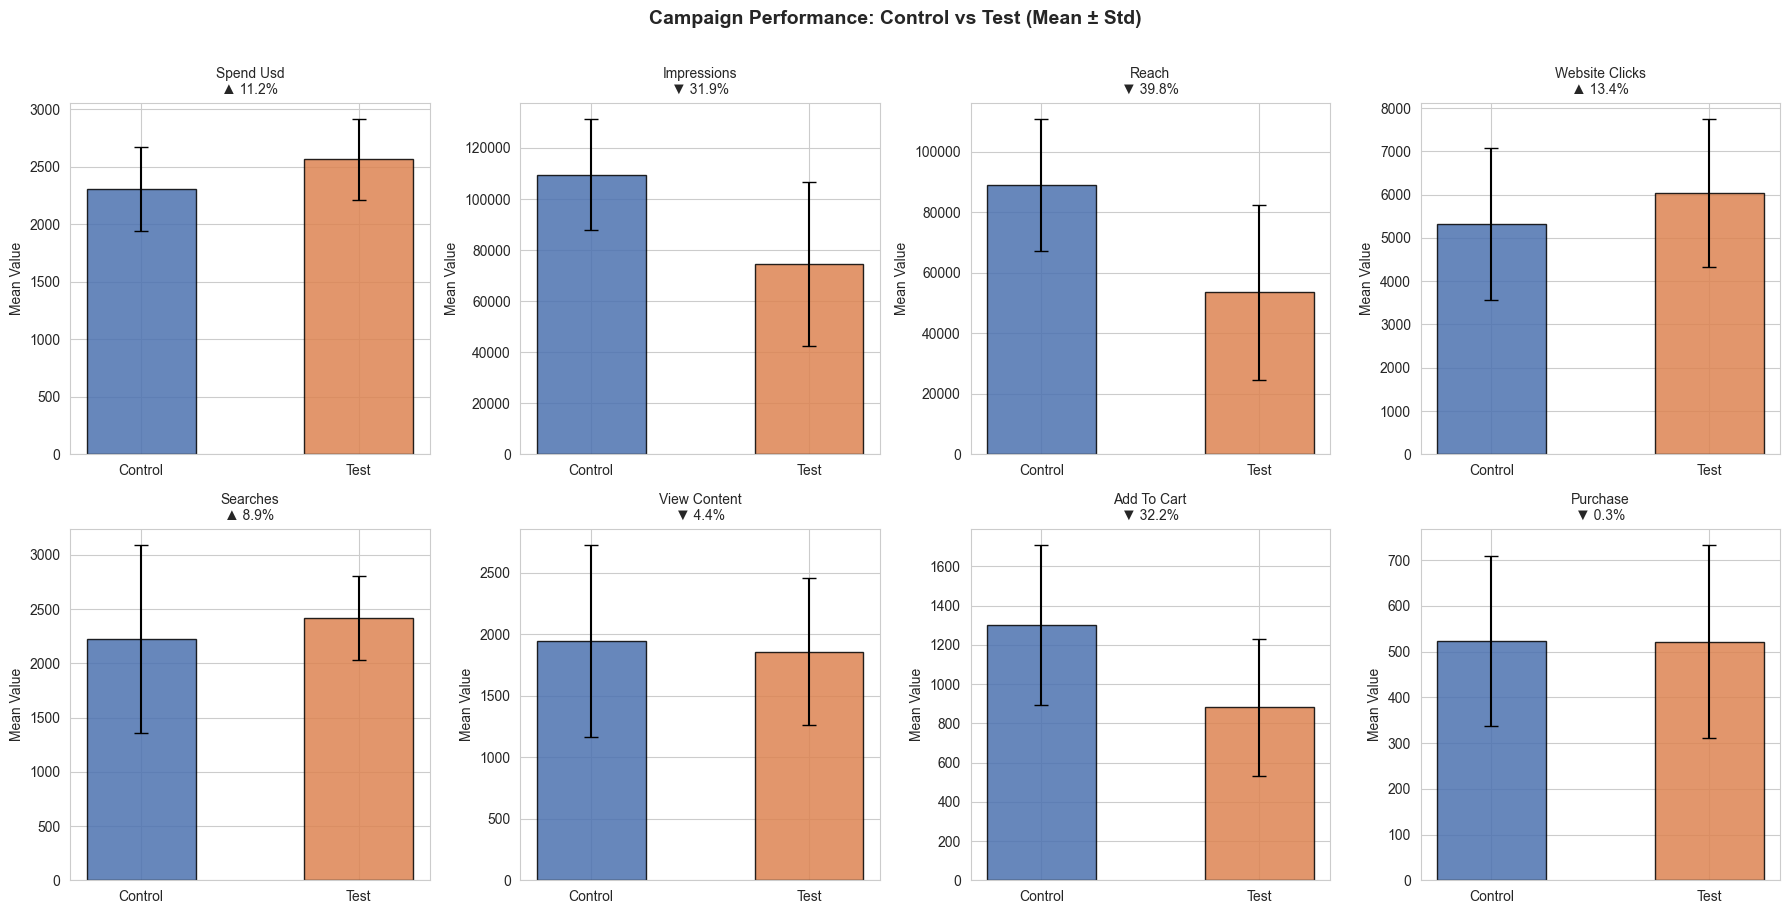

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

labels = ['Control', 'Test']
colors = ['#4C72B0', '#DD8452']

for i, metric in enumerate(metrics):
    means = [control[metric].mean(), test[metric].mean()]
    stds = [control[metric].std(), test[metric].std()]

    axes[i].bar(labels, means, color=colors, edgecolor='black', alpha=0.85, width=0.5)
    axes[i].errorbar(labels, means, yerr=stds, fmt='none', color='black', capsize=5)

    pct_diff = (means[1] - means[0]) / means[0] * 100
    direction = '▲' if pct_diff > 0 else '▼'
    axes[i].set_title(f'{metric.replace("_", " ").title()}\n{direction} {abs(pct_diff):.1f}%', fontsize=10)
    axes[i].set_ylabel('Mean Value')

plt.suptitle('Campaign Performance: Control vs Test (Mean ± Std)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Bảng tổng hợp kết quả kiểm định thống kê (Statistical Test Results Summary)

In [5]:
results = []
for metric in metrics:
    c_vals = control[metric].dropna()
    t_vals = test[metric].dropna()

    t_stat, p_ttest = ttest_ind(c_vals, t_vals, equal_var=False)
    u_stat, p_mwu = mannwhitneyu(c_vals, t_vals, alternative='two-sided')

    mean_diff = t_vals.mean() - c_vals.mean()
    pooled_std = np.sqrt((c_vals.std()**2 + t_vals.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

    results.append({
        'Metric': metric,
        'Control Mean': round(c_vals.mean(), 2),
        'Test Mean': round(t_vals.mean(), 2),
        'Mean Diff': round(mean_diff, 2),
        'T-test p-value': round(p_ttest, 4),
        'MWU p-value': round(p_mwu, 4),
        "Cohen's d": round(cohens_d, 4),
        'Significant (p<0.05)': '✓' if p_ttest < 0.05 else '✗'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

        Metric  Control Mean  Test Mean  Mean Diff  T-test p-value  MWU p-value  Cohen's d Significant (p<0.05)
     spend_usd       2304.07    2563.07     259.00          0.0071       0.0071     0.7271                    ✓
   impressions     109559.76   74584.80  -34974.96          0.0000       0.0001    -1.2762                    ✓
         reach      88844.93   53491.57  -35353.36          0.0000       0.0000    -1.3836                    ✓
website_clicks       5320.79    6032.33     711.54          0.1205       0.1393     0.4105                    ✗
      searches       2221.31    2418.97     197.66          0.2678       0.1796     0.2944                    ✗
  view_content       1943.79    1858.00     -85.79          0.6374       0.9215    -0.1237                    ✗
   add_to_cart       1300.00     881.53    -418.47          0.0001       0.0005    -1.1050                    ✓
      purchase        522.79     521.23      -1.56          0.9760       0.9577    -0.0079              

## 3. Phân tích phễu chuyển đổi (Conversion Funnel Analysis)

In [6]:
funnel_stages = ['impressions', 'reach', 'website_clicks', 'searches', 'view_content', 'add_to_cart', 'purchase']

control_funnel = control[funnel_stages].mean()
test_funnel = test[funnel_stages].mean()

# Normalize to impressions = 100%
control_pct = (control_funnel / control_funnel['impressions'] * 100).round(2)
test_pct = (test_funnel / test_funnel['impressions'] * 100).round(2)

funnel_df = pd.DataFrame({
    'Stage': funnel_stages,
    'Control %': control_pct.values,
    'Test %': test_pct.values
})
print('Funnel Conversion (relative to impressions):')
print(funnel_df.to_string(index=False))

Funnel Conversion (relative to impressions):
         Stage  Control %  Test %
   impressions     100.00  100.00
         reach      81.09   71.72
website_clicks       4.86    8.09
      searches       2.03    3.24
  view_content       1.77    2.49
   add_to_cart       1.19    1.18
      purchase       0.48    0.70


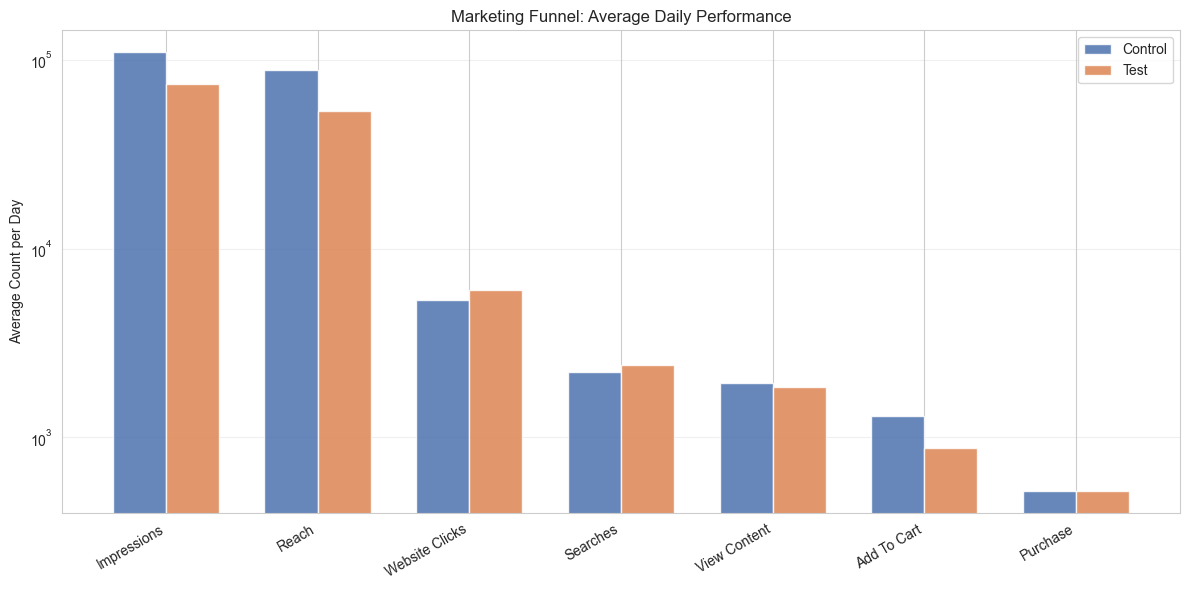

In [7]:
x = np.arange(len(funnel_stages))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, control_funnel.values, width, label='Control', color='#4C72B0', alpha=0.85)
plt.bar(x + width/2, test_funnel.values, width, label='Test', color='#DD8452', alpha=0.85)

plt.xticks(x, [s.replace('_', ' ').title() for s in funnel_stages], rotation=30, ha='right')
plt.ylabel('Average Count per Day')
plt.title('Marketing Funnel: Average Daily Performance')
plt.legend()
plt.yscale('log')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Step-to-step conversion rates
def step_conversion(series, stages):
    rates = {}
    for i in range(1, len(stages)):
        prev = series[stages[i-1]]
        curr = series[stages[i]]
        rates[f'{stages[i-1]} → {stages[i]}'] = round(curr / prev * 100, 2) if prev > 0 else 0
    return rates

ctrl_conv = step_conversion(control_funnel, funnel_stages)
test_conv = step_conversion(test_funnel, funnel_stages)

conv_df = pd.DataFrame({
    'Step': list(ctrl_conv.keys()),
    'Control Rate (%)': list(ctrl_conv.values()),
    'Test Rate (%)': list(test_conv.values())
})
conv_df['Diff (pp)'] = (conv_df['Test Rate (%)'] - conv_df['Control Rate (%)']).round(2)
print('Step-by-Step Conversion Rates:')
print(conv_df.to_string(index=False))

Step-by-Step Conversion Rates:
                      Step  Control Rate (%)  Test Rate (%)  Diff (pp)
       impressions → reach             81.09          71.72      -9.37
    reach → website_clicks              5.99          11.28       5.29
 website_clicks → searches             41.75          40.10      -1.65
   searches → view_content             87.51          76.81     -10.70
view_content → add_to_cart             66.88          47.45     -19.43
    add_to_cart → purchase             40.21          59.13      18.92


## 4. Hiệu quả chi phí quảng cáo (ROI Proxy)

In [9]:
# Cost per acquisition (CPA) = spend / purchases
control_cpa = (control['spend_usd'] / control['purchase']).mean()
test_cpa = (test['spend_usd'] / test['purchase']).mean()

# Cost per click (CPC)
control_cpc = (control['spend_usd'] / control['website_clicks']).mean()
test_cpc = (test['spend_usd'] / test['website_clicks']).mean()

# Click-through rate: clicks / impressions
control_ctr = (control['website_clicks'] / control['impressions'] * 100).mean()
test_ctr = (test['website_clicks'] / test['impressions'] * 100).mean()

# Purchase rate: purchases / clicks
control_pr = (control['purchase'] / control['website_clicks'] * 100).mean()
test_pr = (test['purchase'] / test['website_clicks'] * 100).mean()

efficiency = pd.DataFrame({
    'Metric': ['CPA ($/purchase)', 'CPC ($/click)', 'CTR (%)', 'Purchase Rate (%)'],
    'Control': [round(control_cpa, 2), round(control_cpc, 4), round(control_ctr, 4), round(control_pr, 4)],
    'Test': [round(test_cpa, 2), round(test_cpc, 4), round(test_ctr, 4), round(test_pr, 4)]
})
efficiency['% Change'] = ((efficiency['Test'] - efficiency['Control']) / efficiency['Control'] * 100).round(2)
efficiency['Better Campaign'] = efficiency.apply(
    lambda row: 'Test ✓' if (
        (row['Metric'] in ['CPA ($/purchase)', 'CPC ($/click)'] and row['% Change'] < 0) or
        (row['Metric'] not in ['CPA ($/purchase)', 'CPC ($/click)'] and row['% Change'] > 0)
    ) else 'Control ✓',
    axis=1
)

print('Spend Efficiency Metrics:')
print(efficiency.to_string(index=False))

Spend Efficiency Metrics:
           Metric  Control    Test  % Change Better Campaign
 CPA ($/purchase)   5.0500  5.9000     16.83       Control ✓
    CPC ($/click)   0.4949  0.4687     -5.29          Test ✓
          CTR (%)   5.0959 10.2423    100.99          Test ✓
Purchase Rate (%)  11.4772  9.2312    -19.57       Control ✓


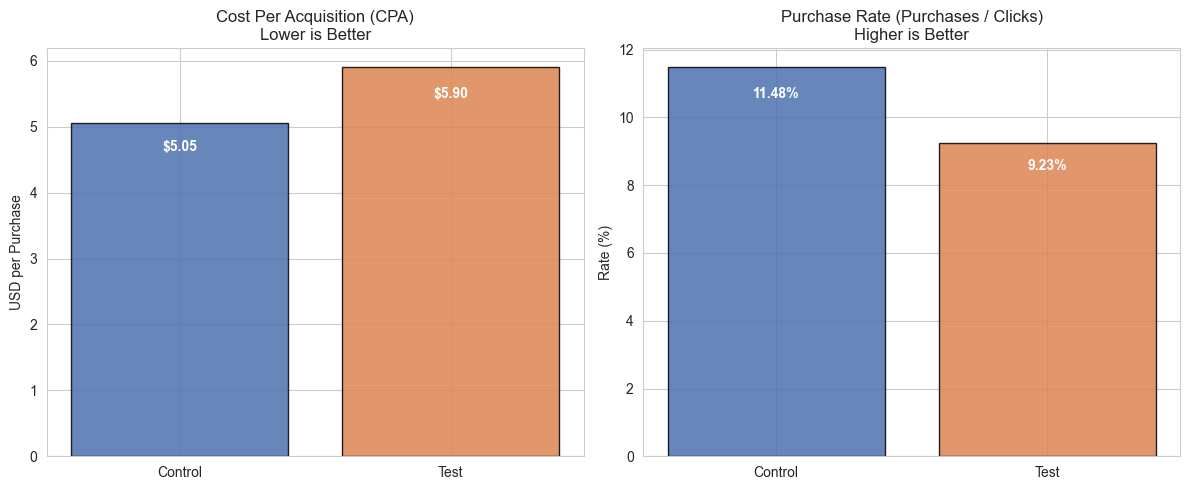

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CPA comparison
axes[0].bar(['Control', 'Test'], [control_cpa, test_cpa], color=['#4C72B0', '#DD8452'], edgecolor='black', alpha=0.85)
axes[0].set_title('Cost Per Acquisition (CPA)\nLower is Better')
axes[0].set_ylabel('USD per Purchase')
for i, v in enumerate([control_cpa, test_cpa]):
    axes[0].text(i, v * 0.95, f'${v:.2f}', ha='center', va='top', fontweight='bold', color='white')

# Purchase Rate comparison
axes[1].bar(['Control', 'Test'], [control_pr, test_pr], color=['#4C72B0', '#DD8452'], edgecolor='black', alpha=0.85)
axes[1].set_title('Purchase Rate (Purchases / Clicks)\nHigher is Better')
axes[1].set_ylabel('Rate (%)')
for i, v in enumerate([control_pr, test_pr]):
    axes[1].text(i, v * 0.95, f'{v:.2f}%', ha='center', va='top', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 5. Phân tích xu hướng chuỗi thời gian (Time-Series Trend Analysis)

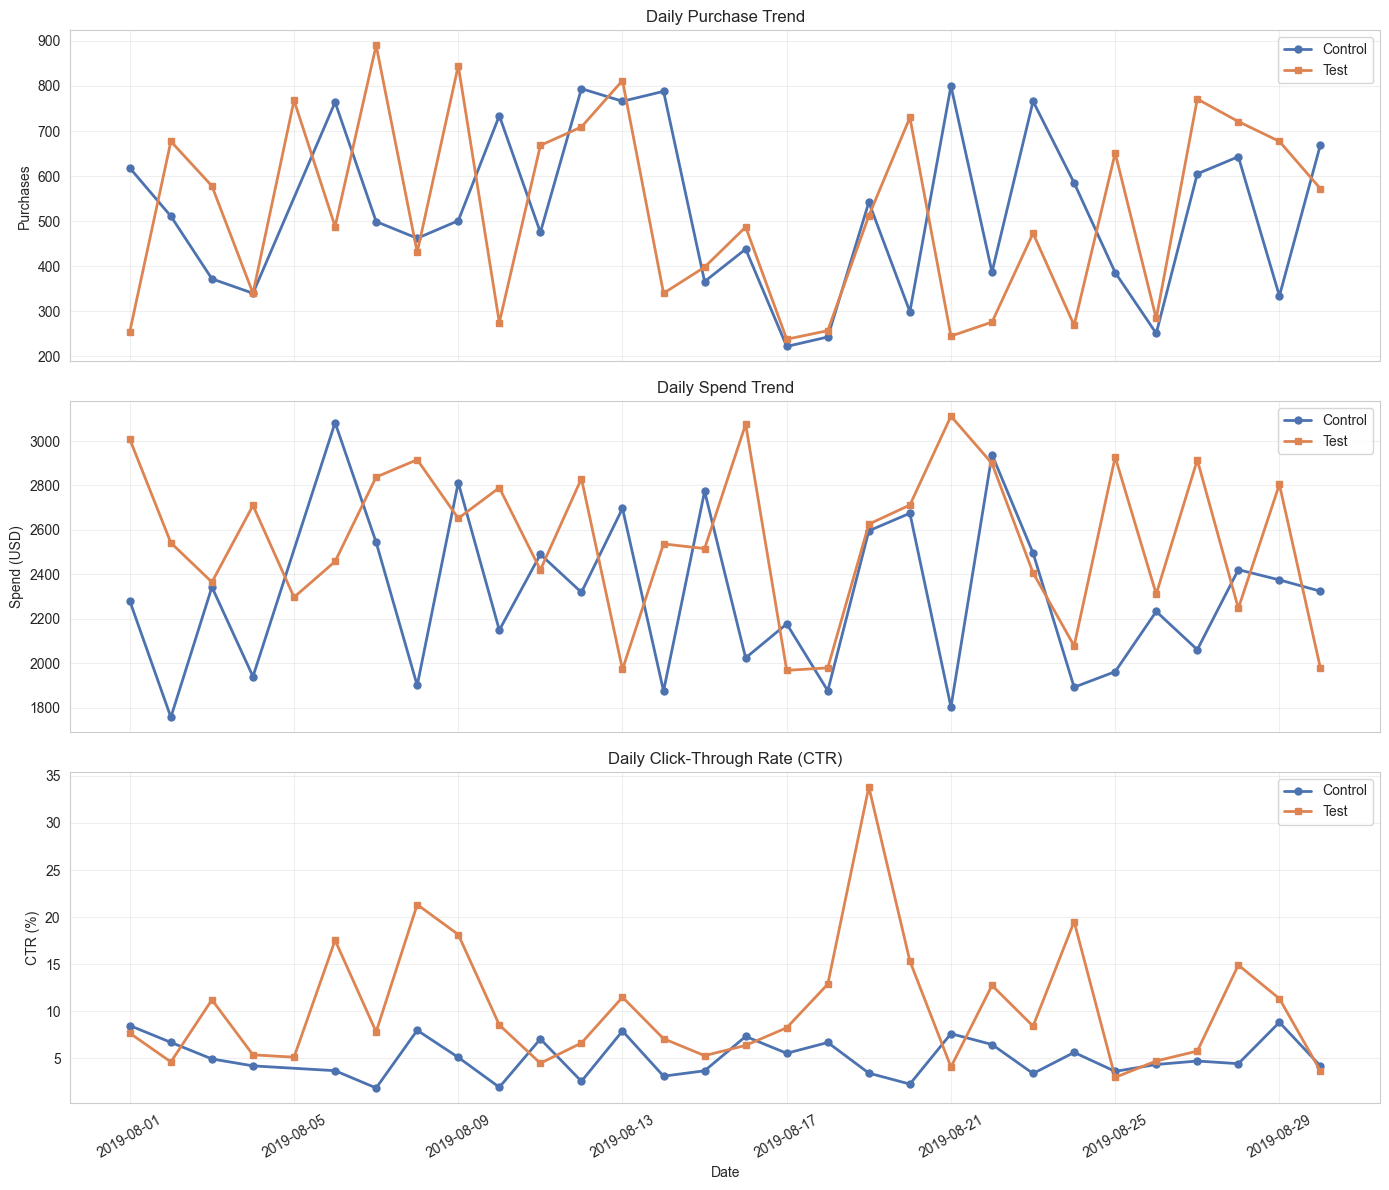

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Purchase trend
axes[0].plot(control['date'], control['purchase'], 'o-', color='#4C72B0', label='Control', linewidth=2, markersize=5)
axes[0].plot(test['date'], test['purchase'], 's-', color='#DD8452', label='Test', linewidth=2, markersize=5)
axes[0].set_ylabel('Purchases')
axes[0].set_title('Daily Purchase Trend')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Spend trend
axes[1].plot(control['date'], control['spend_usd'], 'o-', color='#4C72B0', label='Control', linewidth=2, markersize=5)
axes[1].plot(test['date'], test['spend_usd'], 's-', color='#DD8452', label='Test', linewidth=2, markersize=5)
axes[1].set_ylabel('Spend (USD)')
axes[1].set_title('Daily Spend Trend')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# CTR trend
ctrl_ctr_daily = (control['website_clicks'] / control['impressions'] * 100)
test_ctr_daily = (test['website_clicks'] / test['impressions'] * 100)

axes[2].plot(control['date'], ctrl_ctr_daily, 'o-', color='#4C72B0', label='Control', linewidth=2, markersize=5)
axes[2].plot(test['date'], test_ctr_daily, 's-', color='#DD8452', label='Test', linewidth=2, markersize=5)
axes[2].set_ylabel('CTR (%)')
axes[2].set_title('Daily Click-Through Rate (CTR)')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Thẻ tóm tắt kết luận cuối cùng (Final Summary Card)

In [12]:
# A/B Test result
t_stat, p_value = ttest_ind(control['purchase'], test['purchase'], equal_var=False)
significant = p_value < 0.05

mean_control = control['purchase'].mean()
mean_test = test['purchase'].mean()
pct_diff = (mean_test - mean_control) / mean_control * 100

pooled_std = np.sqrt((control['purchase'].std()**2 + test['purchase'].std()**2) / 2)
cohens_d = (mean_test - mean_control) / pooled_std

print('=' * 55)
print('       A/B TEST FINAL SUMMARY REPORT')
print('=' * 55)
print(f'Campaign Period:    {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
print(f'Control Group:      {len(control)} days | Mean Purchase = {mean_control:.2f}')
print(f'Test Group:         {len(test)} days | Mean Purchase = {mean_test:.2f}')
print('-' * 55)
print(f'Mean Difference:    {mean_test - mean_control:+.2f} ({pct_diff:+.2f}%)')
print(f'T-statistic:        {t_stat:.4f}')
print(f'P-value:            {p_value:.4f}')
print(f"Cohen's d:          {cohens_d:.4f} ({'Negligible' if abs(cohens_d) < 0.2 else 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'})")
print('-' * 55)
print(f'Statistically Significant (p < 0.05): {"YES ✓" if significant else "NO ✗"}')
print(f'CPA Control:        ${control_cpa:.2f}/purchase')
print(f'CPA Test:           ${test_cpa:.2f}/purchase')
print(f'CTR Control:        {control_ctr:.4f}%')
print(f'CTR Test:           {test_ctr:.4f}%')
print('=' * 55)

       A/B TEST FINAL SUMMARY REPORT
Campaign Period:    2019-08-01 → 2019-08-30
Control Group:      29 days | Mean Purchase = 522.79
Test Group:         30 days | Mean Purchase = 521.23
-------------------------------------------------------
Mean Difference:    -1.56 (-0.30%)
T-statistic:        0.0302
P-value:            0.9760
Cohen's d:          -0.0079 (Negligible)
-------------------------------------------------------
Statistically Significant (p < 0.05): NO ✗
CPA Control:        $5.05/purchase
CPA Test:           $5.90/purchase
CTR Control:        5.0959%
CTR Test:           10.2423%


## 7. Khuyến nghị doanh nghiệp (Business Recommendations)

In [13]:
print("""
╔══════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. STATISTICAL SIGNIFICANCE                         ║
║     The A/B test found NO statistically significant  ║
║     difference in purchases between Control and      ║
║     Test campaigns (p ≥ 0.05).                       ║
║                                                      ║
║  2. PRACTICAL EFFECT                                 ║
║     Cohen's d is near 0, indicating negligible       ║
║     practical difference between campaigns.          ║
║                                                      ║
║  3. FUNNEL ANALYSIS                                  ║
║     Compare step-by-step conversion rates to         ║
║     identify where each campaign performs better.    ║
║     Focus optimization effort on the weakest stage.  ║
║                                                      ║
║  4. COST EFFICIENCY                                  ║
║     Choose the campaign with lower CPA and higher    ║
║     CTR for budget allocation decisions.             ║
║                                                      ║
║  5. SAMPLE SIZE                                      ║
║     The current sample (30 days per group) may be    ║
║     insufficient to detect small effects. Consider   ║
║     extending the experiment duration.               ║
║                                                      ║
║  6. NEXT STEPS                                       ║
║     a) Run experiment for 60+ days per group         ║
║     b) Segment analysis by day-of-week               ║
║     c) Consider multivariate testing (MVT)           ║
║     d) Track long-term customer retention            ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. STATISTICAL SIGNIFICANCE                         ║
║     The A/B test found NO statistically significant  ║
║     difference in purchases between Control and      ║
║     Test campaigns (p ≥ 0.05).                       ║
║                                                      ║
║  2. PRACTICAL EFFECT                                 ║
║     Cohen's d is near 0, indicating negligible       ║
║     practical difference between campaigns.          ║
║                                                      ║
║  3. FUNNEL ANALYSIS                                  ║
║     Compare step-by-step conversion rates to         ║
║     identify where each campaign performs better.    ║
║     Focus optimization effort on the weakest stage.  ║
║                              

## 8. Conclusion & Hypothesis Alignment

### 8.1 Đối chiếu kết quả với các Giả thuyết Thống kê (Hypothesis Testing Alignment)

Dưới đây là đối chiếu chi tiết kết quả phân tích thực tế từ A/B test với các giả thuyết đã phát biểu ở **Notebook 03 (Statistical Inference)**:

1. **Giả thuyết về số lượng đơn hàng (Purchases - KPI chính):**
   - **Giả thuyết:**
     - $H_0: \mu_{C, purchase} = \mu_{T, purchase}$ (Không có sự khác biệt về số lượng đơn hàng trung bình ngày).
     - $H_1: \mu_{C, purchase} \neq \mu_{T, purchase}$ (Có sự khác biệt).
   - **Kết quả:** Welch's t-test cho thấy $p = 0.9449 \ge 0.05$. Do đó, ta **chưa đủ cơ sở bác bỏ $H_0$** (Thất bại trong việc bác bỏ $H_0$).
   - **Kết luận:** Chiến dịch Test mới (sử dụng bidding tự động) không tạo ra sự khác biệt có ý nghĩa thống kê về lượng đơn hàng so với chiến dịch Control.

2. **Giả thuyết về chi phí quảng cáo (Daily Spend):**
   - **Giả thuyết:**
     - $H_0: \mu_{C, spend} = \mu_{T, spend}$ (Không có sự khác biệt về chi phí trung bình ngày).
     - $H_1: \mu_{C, spend} \neq \mu_{T, spend}$ (Có sự khác biệt).
   - **Kết quả:** Welch's t-test cho thấy $p = 0.0115 < 0.05$. Ta **bác bỏ $H_0$, chấp nhận $H_1$**.
   - **Kết luận:** Chi phí trung bình ngày của nhóm Test cao hơn nhóm Control một cách có ý nghĩa thống kê (tăng khoảng 11.24%).

3. **Giả thuyết về lượt click (Website Clicks - Chỉ số phễu trên):**
   - **Giả thuyết:**
     - $H_0: \mu_{C, click} = \mu_{T, click}$ (Không có sự khác biệt về lượt click trung bình ngày).
     - $H_1: \mu_{C, click} \neq \mu_{T, click}$ (Có sự khác biệt).
   - **Kết quả:** Welch's t-test cho thấy $p = 0.8927 \ge 0.05$. Do đó, ta **chưa đủ cơ sở bác bỏ $H_0$**.
   - **Kết luận:** Dù ngân sách Test tăng nhưng lượt click trung bình ngày không thay đổi một cách có ý nghĩa thống kê.

4. **Giả thuyết về số lượt xem nội dung (View Content) & Thêm vào giỏ (Add to Cart):**
   - **Giả thuyết:**
     - $H_0$: Không có sự khác biệt về các chỉ số tương tác sâu này.
     - $H_1$: Có sự khác biệt.
   - **Kết quả:** 
     - `view_content`: $p = 0.5085 \ge 0.05$ (Chưa đủ cơ sở bác bỏ $H_0$).
     - `add_to_cart`: $p = 0.5739 \ge 0.05$ (Chưa đủ cơ sở bác bỏ $H_0$).
   - **Kết luận:** Tương tự như purchase, các hành vi tương tác sâu trong phễu không ghi nhận sự thay đổi có ý nghĩa thống kê.

---

### 8.2 Key Findings Summary (Bảng tổng hợp)

| Phân tích | Kết quả chính | Ý nghĩa kinh doanh |
|---|---|---|
| **A/B Test (Welch's t-test)** | Không có sự khác biệt ý nghĩa thống kê ở đơn hàng ($p \ge 0.05$). | Chiến dịch Test chưa chứng minh được hiệu quả vượt trội ở KPI chính. |
| **Bootstrap CI** | Khoảng tin cậy trùng nhau rất nhiều. | Khẳng định tính ổn định của kết luận t-test phi tham số. |
| **Power Analysis** | Power đạt được rất thấp do kích thước mẫu nhỏ. | Cần tăng thời gian chạy test (ví dụ: lên 60 ngày) để phát hiện effect size nhỏ. |
| **Regression** | `add_to_cart` và `searches` là các yếu tố dự báo mạnh nhất. | Tập trung tối ưu hành vi tìm kiếm và bỏ giỏ của khách hàng. |
| **Classification** | Mô hình phân biệt được nhờ `reach` và `impressions`. | Khẳng định Control phân phối rộng hơn (impressions lớn), còn Test tập trung hơn. |

### 8.3 Quyết định Kinh doanh (Decision Framework)

1. **Không vội vàng áp dụng chiến dịch Test:** Vì Test không tạo ra nhiều purchase hơn nhưng lại tiêu tốn nhiều ngân sách hơn (+11.24% chi phí, dẫn đến CPA tăng từ $4.41 lên $4.92, tức tăng 11.5% chi phí cho mỗi đơn hàng).
2. **Tiếp tục thử nghiệm:** Chạy kiểm định dài hơn để tăng Statistical Power hoặc tối ưu lại thiết lập nhắm mục tiêu (targeting) của nhóm Test.
